In [3]:
# Librerías 
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.signal import firwin, filtfilt, welch
from scipy import stats
import mne

In [4]:
mne.set_log_level('WARNING')

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
sns.set_theme(style='whitegrid', palette='muted')

print("Librerías cargadas correctamente.")
print("Versión MNE:", mne.__version__)

Librerías cargadas correctamente.
Versión MNE: 1.12.1


In [5]:
# Parámetros globales del dataset 
FS          = 160          # frecuencia de muestreo (Hz)
CANALES_INT = ['C3', 'Cz', 'C4']   # electrodos de la corteza motora
NPERSEG     = 256          # muestras por segmento en Welch (≈ 1.6 s)

# Bandas de frecuencia EEG relevantes
BANDAS = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8, 13),   # alpha / mu
    'mu':    (8, 13),   # alias explícito
    'beta':  (13, 30),
    'gamma': (30, 45),
}

RUNS_REAL_MANOS    = [3, 7, 11]
RUNS_IMAGERY_MANOS = [4, 8, 12]

# T0 = reposo/baseline   T1 = mano izquierda   T2 = mano derecha
LABEL_MAP = {'T0': 'rest', 'T1': 'left', 'T2': 'right'}

In [6]:
import os
import re
from pathlib import Path

# 1. Configuración dinámica
CANTIDAD_SUJETOS = 50
sujetos_objetivo = [f"{i:03d}" for i in range(1, CANTIDAD_SUJETOS + 1)]
archivos_encontrados = []

# Mapeo de Runs según protocolo PhysioNet
# Real: 3, 4, 7, 8, 11, 12 | Imagery: 5, 6, 9, 10, 13, 14
MAPEO_RUNS = {
    **{r: 'Real' for r in [3, 4, 7, 8, 11, 12]},
    **{r: 'Imagery' for r in [5, 6, 9, 10, 13, 14]}
}

print(f"--- INICIANDO BÚSQUEDA DE ARCHIVOS (Sujetos 001 al {CANTIDAD_SUJETOS:03d}) ---")

# 2. Búsqueda optimizada
base_path = Path('.') # Directorio actual

for archivo in base_path.rglob('*.set'): # Busca .set en todas las subcarpetas
    nombre = archivo.name
    
    # Ignorar archivos ocultos de macOS (._)
    if nombre.startswith('._'):
        continue
    
    nombre_low = nombre.lower()
    
    # Extraer ID de sujeto y Run con Regex
    sub_match = re.search(r'sub-(\d+)', nombre_low)
    run_match = re.search(r'run-(\d+)', nombre_low)
    
    if sub_match and run_match:
        id_sub = sub_match.group(1)
        run_num = int(run_match.group(1))
        
        # Validar si el sujeto está en nuestro rango y el run es de interés
        if id_sub in sujetos_objetivo and run_num in MAPEO_RUNS:
            archivos_encontrados.append({
                'subject': f"sub-{id_sub}",
                'run': run_num,
                'task_type': MAPEO_RUNS[run_num],
                'path': str(archivo)
            })

# 3. Reporte de resultados
total = len(archivos_encontrados)
print(f"¡Éxito! Se encontraron {total} archivos válidos.")

if total > 0:
    # Mostrar cuántos archivos se encontraron por tipo para verificar balance
    from collections import Counter
    conteo = Counter([a['task_type'] for a in archivos_encontrados])
    print(f"Distribución: {conteo['Real']} Reales | {conteo['Imagery']} Imaginarios")
    
    print("\nEjemplo del último sujeto encontrado:")
    print(f"Sujeto: {archivos_encontrados[-1]['subject']} | Tarea: {archivos_encontrados[-1]['task_type']}")
else:
    print("\n[!] ADVERTENCIA: No se encontraron archivos. Revisa la estructura de carpetas.")

--- INICIANDO BÚSQUEDA DE ARCHIVOS (Sujetos 001 al 050) ---
¡Éxito! Se encontraron 600 archivos válidos.
Distribución: 300 Reales | 300 Imaginarios

Ejemplo del último sujeto encontrado:
Sujeto: sub-021 | Tarea: Real


In [7]:
import numpy as np
from scipy.signal import firwin, filtfilt, welch

FS = 160.0 
NPERSEG = int(FS * 2) 

# Diccionario de bandas de frecuencia
BANDAS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'mu': (8, 13),    
    'beta': (13, 30),
    'gamma': (30, 45)
}
import numpy as np
from scipy.signal import firwin, filtfilt, welch

import numpy as np
from scipy.signal import firwin, filtfilt, welch

def procesar_eeg(signal, fs, verbose=False):
    """
    Versión unificada para Bioingeniería (Compatible con Python 3.14 y Matplotlib)
    """
    # 1. Señal cruda (la guardamos tal cual)
    raw_signal = signal

    # 2. Filtro FIR pasabanda 1-45 Hz
    numtaps = 101
    b = firwin(numtaps, [1.0, 45.0], pass_zero=False, fs=fs, window='hamming')
    filtered = filtfilt(b, [1.0], signal)

    # 3. Remoción de media (Zero-mean / Detrend)
    detrended = filtered - np.mean(filtered)

    # 4. Cálculo de PSD (Welch)
    freqs, psd = welch(detrended, fs=fs, nperseg=int(2*fs), window='hann')

    # 5. Potencias por banda (con corrección para Python 3.14)
    def integrar(y, x):
        if hasattr(np, 'trapezoid'): return np.trapezoid(y, x)
        return np.trapz(y, x)

    potencias = {}
    # Usamos las bandas globales definidas antes (delta, theta, mu, beta, gamma)
    for banda, (flo, fhi) in BANDAS.items():
        mask = (freqs >= flo) & (freqs <= fhi)
        potencias[banda] = integrar(psd[mask], freqs[mask])

    if verbose:
        print("\nPotencias calculadas:")
        for k, v in potencias.items(): print(f"  {k}: {v:.4e} µV²")

    # Retornamos el diccionario con las llaves que tu código de gráficas espera
    return {
        'raw': raw_signal,
        'filtered': filtered,
        'detrended': detrended,
        'freqs': freqs,
        'psd': psd,
        'potencias': potencias
    }

print("Función procesar_eeg sincronizada con el código de graficación.")

Función procesar_eeg sincronizada con el código de graficación.


--- VISUALIZACIÓN MULTICANAL ---
Archivo: sub-007 | Run: 13 | Tarea: Imagery


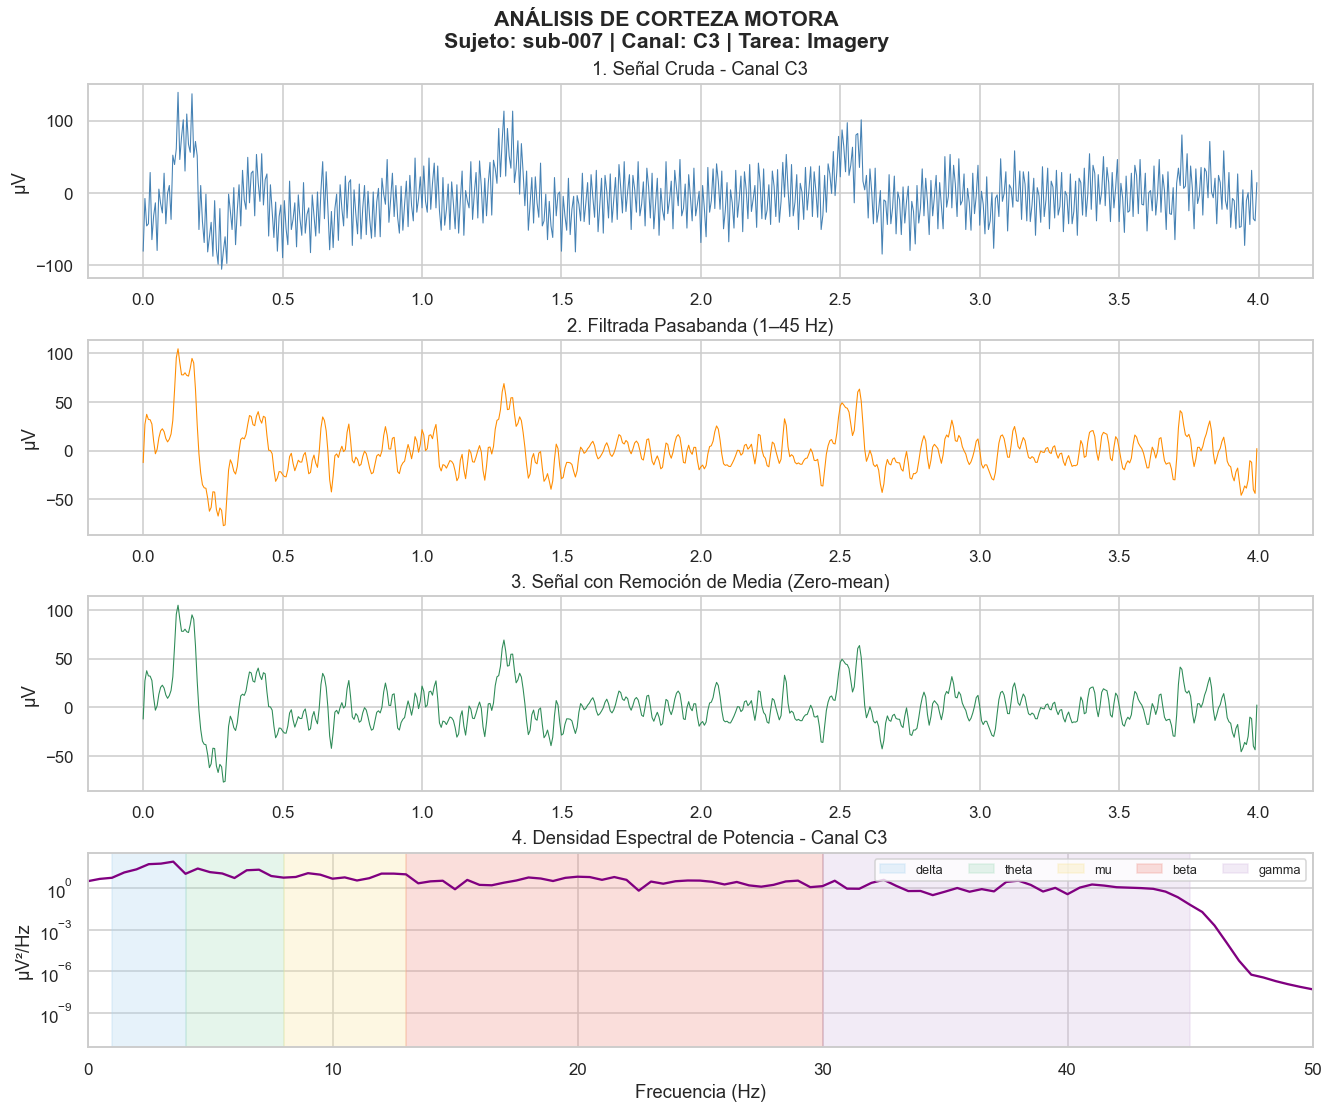

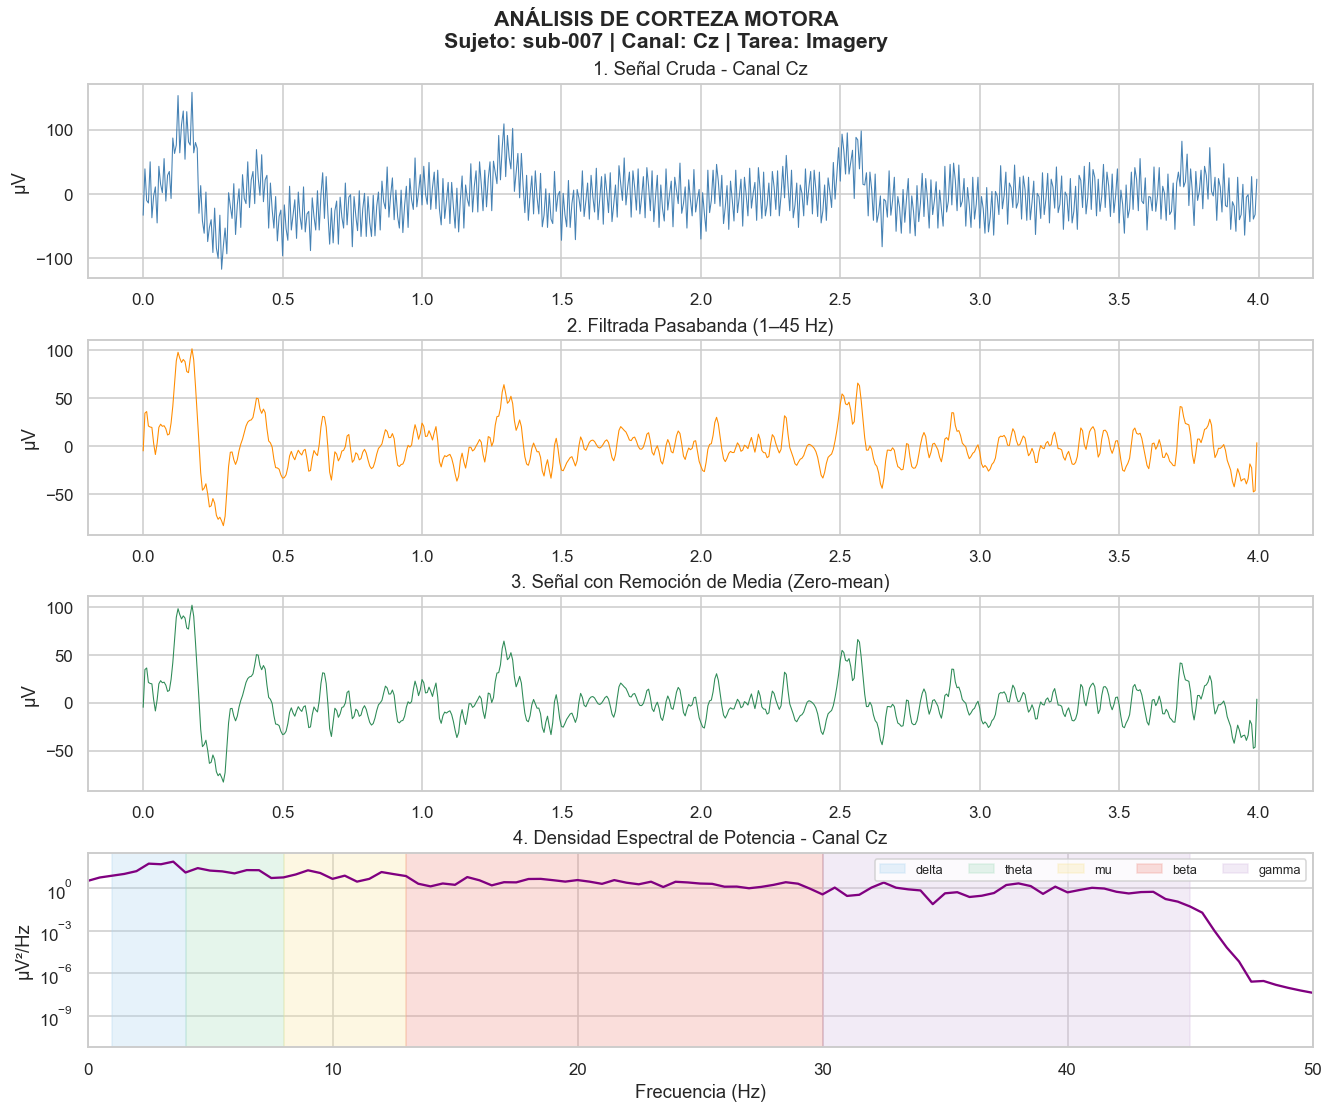

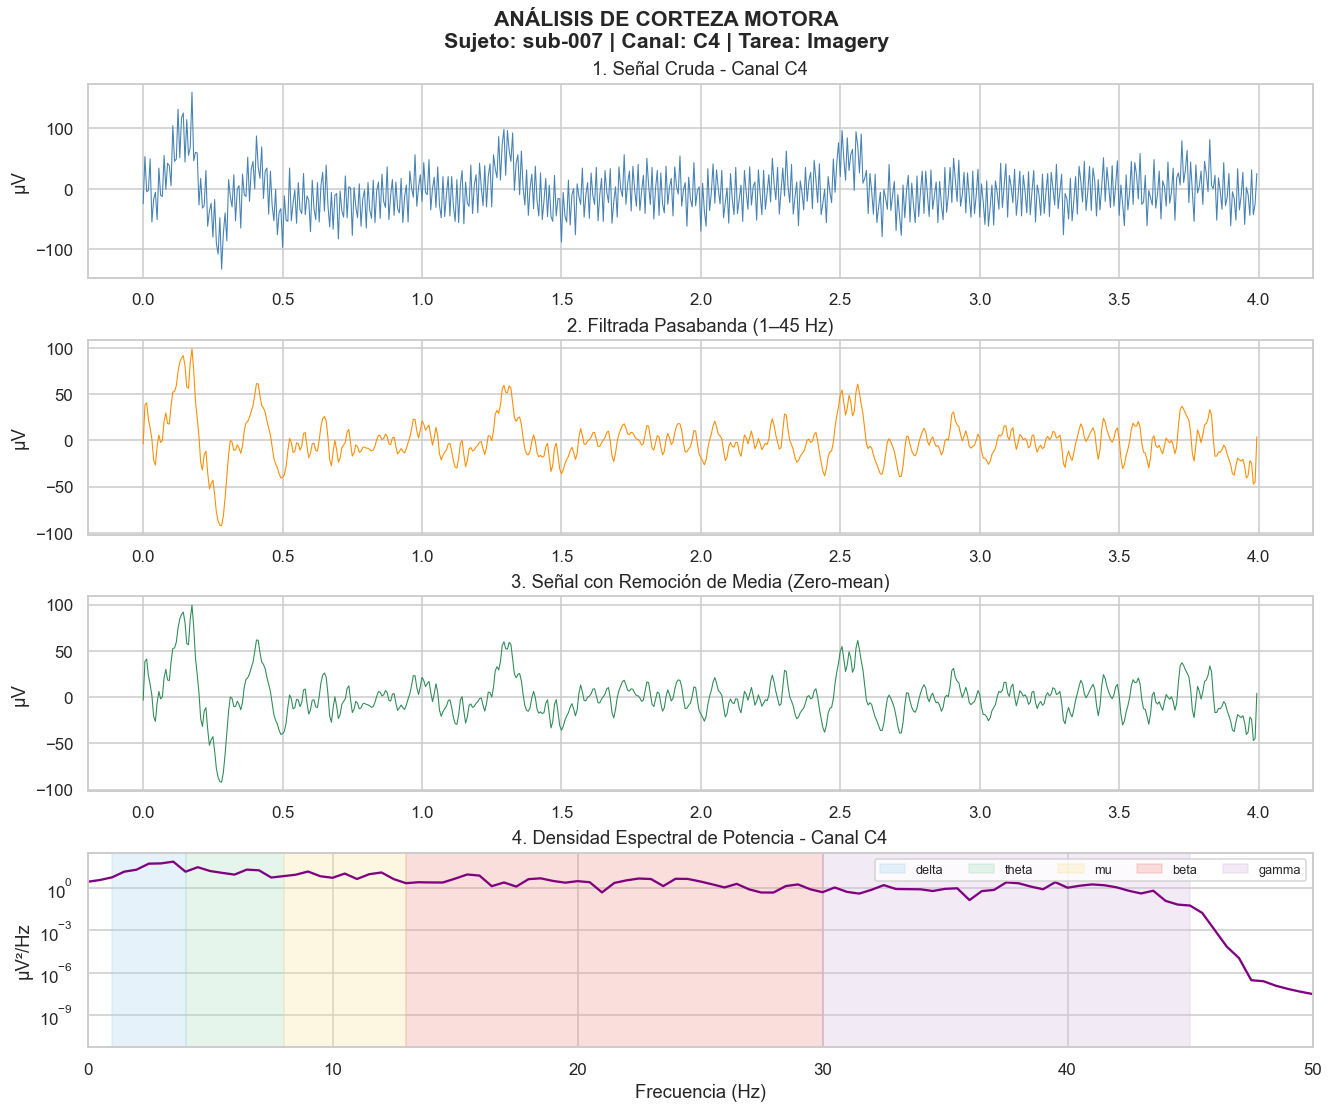

In [8]:
import mne
import matplotlib.pyplot as plt
import numpy as np

# 1. Configuración de canales de interés según metodología
CANALES_MOTOR = ['C3', 'Cz', 'C4']

# 2. Selección del archivo de demostración (Imagery)
meta_demo = next((a for a in archivos_encontrados if a['task_type'] == 'Imagery'), archivos_encontrados[0])

print(f"--- VISUALIZACIÓN MULTICANAL ---")
print(f"Archivo: {meta_demo['subject']} | Run: {meta_demo['run']} | Tarea: {meta_demo['task_type']}")

# 3. Cargar y limpiar canales
raw = mne.io.read_raw_eeglab(meta_demo['path'], preload=True, verbose=False)
raw.rename_channels({ch: ch.rstrip('.') for ch in raw.ch_names})

# 4. Extraer el primer evento T1 (inicio de tarea)
eventos, mapa = mne.events_from_annotations(raw, verbose=False)
id_interes = next((codigo for nombre, codigo in mapa.items() if 'T1' in nombre or 'left' in nombre.lower()), None)

if id_interes is None:
    id_interes = eventos[0][2]

primer_evento = next(ev for ev in eventos if ev[2] == id_interes)
onset_muestras = primer_evento[0]
FS_REAL = raw.info['sfreq']
muestras_duracion = int(4.0 * FS_REAL)

# 5. Bucle para generar una gráfica por cada canal
for ch_name in CANALES_MOTOR:
    if ch_name not in raw.ch_names:
        print(f"Saltando {ch_name}: No encontrado en este archivo.")
        continue
    
    # Extraer segmento del canal actual
    idx_canal = raw.ch_names.index(ch_name)
    data_v, _ = raw[idx_canal, onset_muestras : onset_muestras + muestras_duracion]
    señal_uV = data_v[0] * 1e6
    t_demo = np.arange(len(señal_uV)) / FS_REAL

    # Procesar señal con tu función
    res = procesar_eeg(señal_uV, fs=FS_REAL, verbose=False)

    # 6. Graficar los 4 paneles para el canal actual
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), constrained_layout=True)
    fig.suptitle(f'ANÁLISIS DE CORTEZA MOTORA\nSujeto: {meta_demo["subject"]} | Canal: {ch_name} | Tarea: {meta_demo["task_type"]}', 
                 fontsize=14, fontweight='bold')

    # Panel 1: Cruda
    axes[0].plot(t_demo, res['raw'], color='steelblue', lw=0.7)
    axes[0].set_title(f'1. Señal Cruda - Canal {ch_name}')
    axes[0].set_ylabel('µV')

    # Panel 2: Filtrada
    axes[1].plot(t_demo, res['filtered'], color='darkorange', lw=0.7)
    axes[1].set_title('2. Filtrada Pasabanda (1–45 Hz)')
    axes[1].set_ylabel('µV')

    # Panel 3: Sin Media
    axes[2].plot(t_demo, res['detrended'], color='seagreen', lw=0.7)
    axes[2].set_title('3. Señal con Remoción de Media (Zero-mean)')
    axes[2].set_ylabel('µV')

    # Panel 4: PSD (Potencia)
    ax4 = axes[3]
    ax4.semilogy(res['freqs'], res['psd'], color='purple', lw=1.5)
    colores_banda = {'delta': '#AED6F1', 'theta': '#A9DFBF', 'mu': '#F9E79F', 'beta': '#F1948A', 'gamma': '#D7BDE2'}

    for banda, (flo, fhi) in BANDAS.items():
        ax4.axvspan(flo, fhi, color=colores_banda[banda], alpha=0.3, label=banda)

    ax4.set_xlim(0, 50)
    ax4.set_title(f'4. Densidad Espectral de Potencia - Canal {ch_name}')
    ax4.set_xlabel('Frecuencia (Hz)')
    ax4.set_ylabel('µV²/Hz')
    ax4.legend(loc='upper right', ncol=5, fontsize='x-small')

    plt.show()